# Imports der Bibliotheken

In [142]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [143]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/MasterProjekt_Lastprofile.csv', index_col=0)
input_data

#limitieren der Daten auf 3 Wochen
start = 0      # 0 = Anfang des Jahres
input_data = input_data.iloc[start : start + 504]
input_data.index = range(len(input_data)) 

In [144]:
input_data = input_data.drop(columns=["Waerme gesamt (kW)"]).rename(
    columns={"Temp C": "temp","Zone 2-Trinkwarmwasser (kW)": "heat_water","Zone 2-Raumwaerme (kW)": "heat_space",}
)

print(input_data.columns)
input_data = input_data[["temp", "heat_water", "heat_space"]]
input_data.index.name = "index"
input_data.to_csv("Inputs/load_profile_3_weeks.csv", index=True)

Index(['heat_space', 'heat_water', 'temp'], dtype='object')


In [145]:
input_data

,temp,heat_water,heat_space
index,,,
0,6.286,0.2,1.7
1,5.997,0.1,1.7
2,5.705,0.1,1.8
3,5.534,0.0,1.7
4,5.451,0.1,1.8
...,...,...,...
499,-4.842,0.8,5.8
500,-5.690,0.7,5.8
501,-6.235,0.6,5.6


<Axes: xlabel='index'>

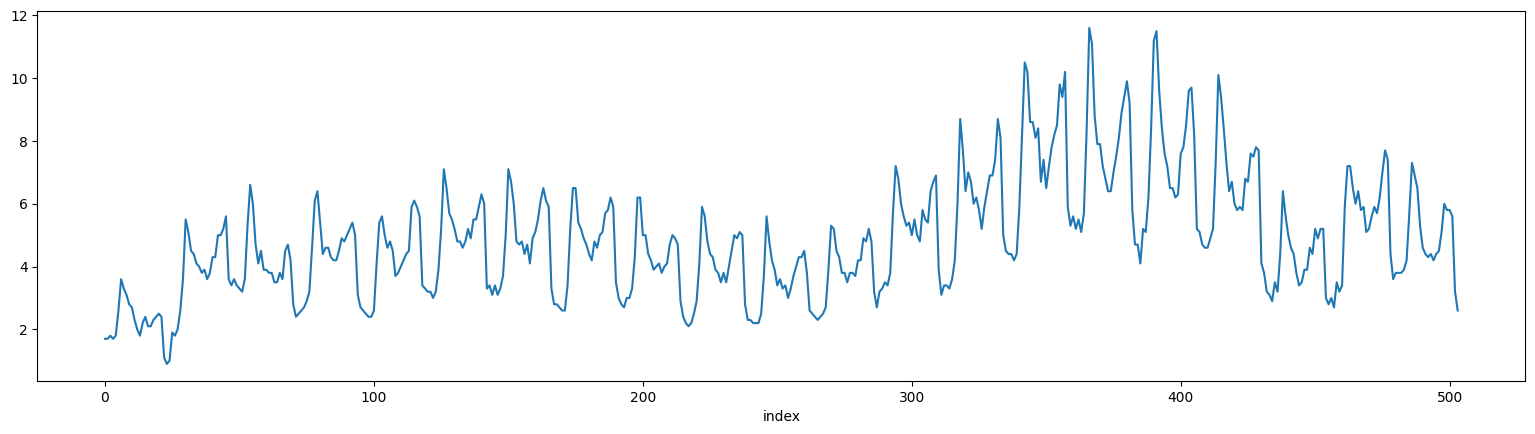

In [146]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
raumwaerme.plot(figsize=(19.2, 4.8))

<Axes: xlabel='index'>

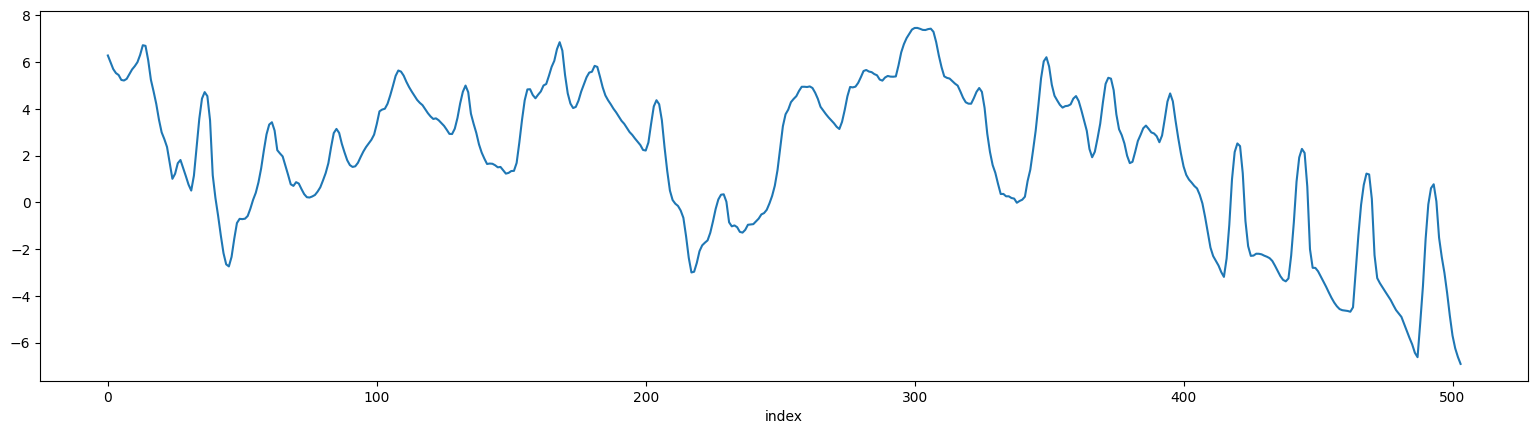

In [147]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
aussentemperatur.plot(figsize=(19.2, 4.8))

# System Eigenschaften

In [148]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
V_layer = (Store_height * Store_base) / 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = 50 #kW Hausanschluss Leistung

In [149]:
V_layer

0.5333333333333333

<Axes: xlabel='index'>

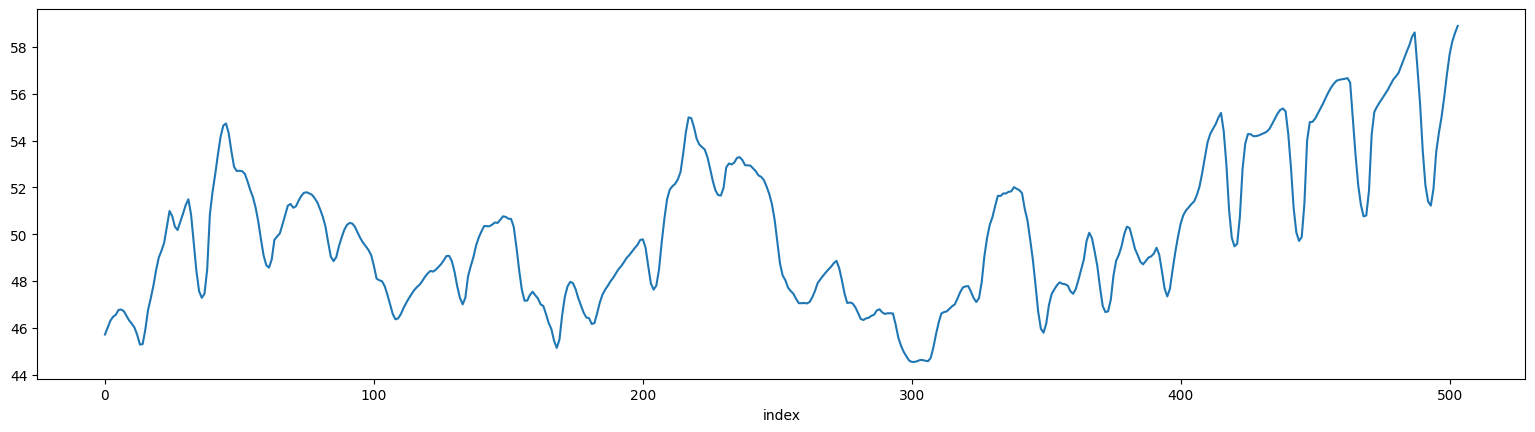

In [150]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
T_flow.plot(figsize=(19.2, 4.8))

In [151]:
# Berechnung der Rücklauftemperatur
T_flow_return = pd.Series([40] * len(input_data))
T_flow_return

0      40
1      40
2      40
3      40
4      40
       ..
499    40
500    40
501    40
502    40
503    40
Length: 504, dtype: int64

# Modellerstellung

In [152]:
# Aufbau des Modells
n = ph.HeatNetwork()
n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last'
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = input_data['heat_space'],
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='temperature',  # konstante Temperatur in den Schichten
      height=Store_height,
      base=Store_base,      
      cyclic=False,
      U_wall=0.15,
      V_initial = [V_layer, V_layer, V_layer],  # Volumen in den Schichten m³                 
      T_layer = [60,55,50],  # Beispieltemperaturen für die Schichten
      T_return = T_flow_return # Rücklauftemperatur des Heizsystems, °C
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp',
      bus0 = 'electricity',
      p_nom = HP_power,
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_max = 65,        # max. lieferbare Temperatur der WP
      #T_sink = T_at_0,  
      heat_source = 'air'
)

In [153]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [154]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'T_return': HeatStore    hs
 snapshot       
 0          40.0
 1          40.0
 2          40.0
 3          40.0
 4          40.0
 ...         ...
 499        40.0
 500        40.0
 501        40.0
 502        40.0
 503        40.0
 
 [504 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 

In [155]:
n.optimize(solver_name = 'gurobi')

Index(['electricity'], dtype='object', name='Bus')


INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.07s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-73enrswa.lp
Reading time = 0.02 seconds
obj: 12096 rows, 5040 columns, 21669 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 12096 rows, 5040 columns and 21669 nonzeros
Model fingerprint: 0x3ea479c0
Coefficient statistics:
  Matrix range     [4e-01, 2e+01]
  Objective range  [3e-01, 3e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 5e+01]
Presolve removed 9579 rows and 1011 columns
Presolve time: 0.01s
Presolved: 2517 rows, 4029 columns, 9574 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   3.375413e+02   0.000000e+00      0s
    3269    3.6847047e+02   0.000000e+00   0.000000e+00      0s

Solved in 3269 iterations and 

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5040 primals, 12096 duals
Objective: 3.68e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-fix-layer-upper, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.


PyPSA Heat Network
Components:
 - Bus: 1
 - Generator: 1
 - HeatLoad: 1
 - HeatPump: 1
 - HeatStore: 1
 - Load: 1
 - HeatLoad: 1
 - HeatPump: 1
 - HeatStore: 1
Snapshots: 504

In [156]:
n.heat_pumps_t

{'T_source':              hp
 snapshot       
 0         6.286
 1         5.997
 2         5.705
 3         5.534
 4         5.451
 ...         ...
 499      -4.842
 500      -5.690
 501      -6.235
 502      -6.605
 503      -6.903
 
 [504 rows x 1 columns],
 'T_nom': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'p_min_pu': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 5

In [157]:
heatstore_daten=n.heat_stores_t.T

In [158]:
n.heat_stores_t

{'T_amb': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
 
 [504 rows x 0 columns],
 'T_return': HeatStore    hs
 snapshot       
 0          40.0
 1          40.0
 2          40.0
 3          40.0
 4          40.0
 ...         ...
 499        40.0
 500        40.0
 501        40.0
 502        40.0
 503        40.0
 
 [504 rows x 1 columns],
 'T': Empty DataFrame
 Columns: []
 Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 

# Python Ergebnisse

In [159]:
#ph.plot.plot_stratified_heat_store(n, 'hs', sns = n.snapshots)

In [ ]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten und Schichtdaten
v_hs_60 = n.heat_stores_t.V.iloc[:, 0]
v_hs_55 = n.heat_stores_t.V.iloc[:, 1]
v_hs_50 = n.heat_stores_t.V.iloc[:, 2]
T_return = n.heat_stores_t.T_return


p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
COP = n.heat_pumps_t.COP
p_hp_60 = p_heat[('hp', 60)]
p_hp_55 = p_heat[('hp', 55)]
p_hp_50 = p_heat[('hp', 50)]

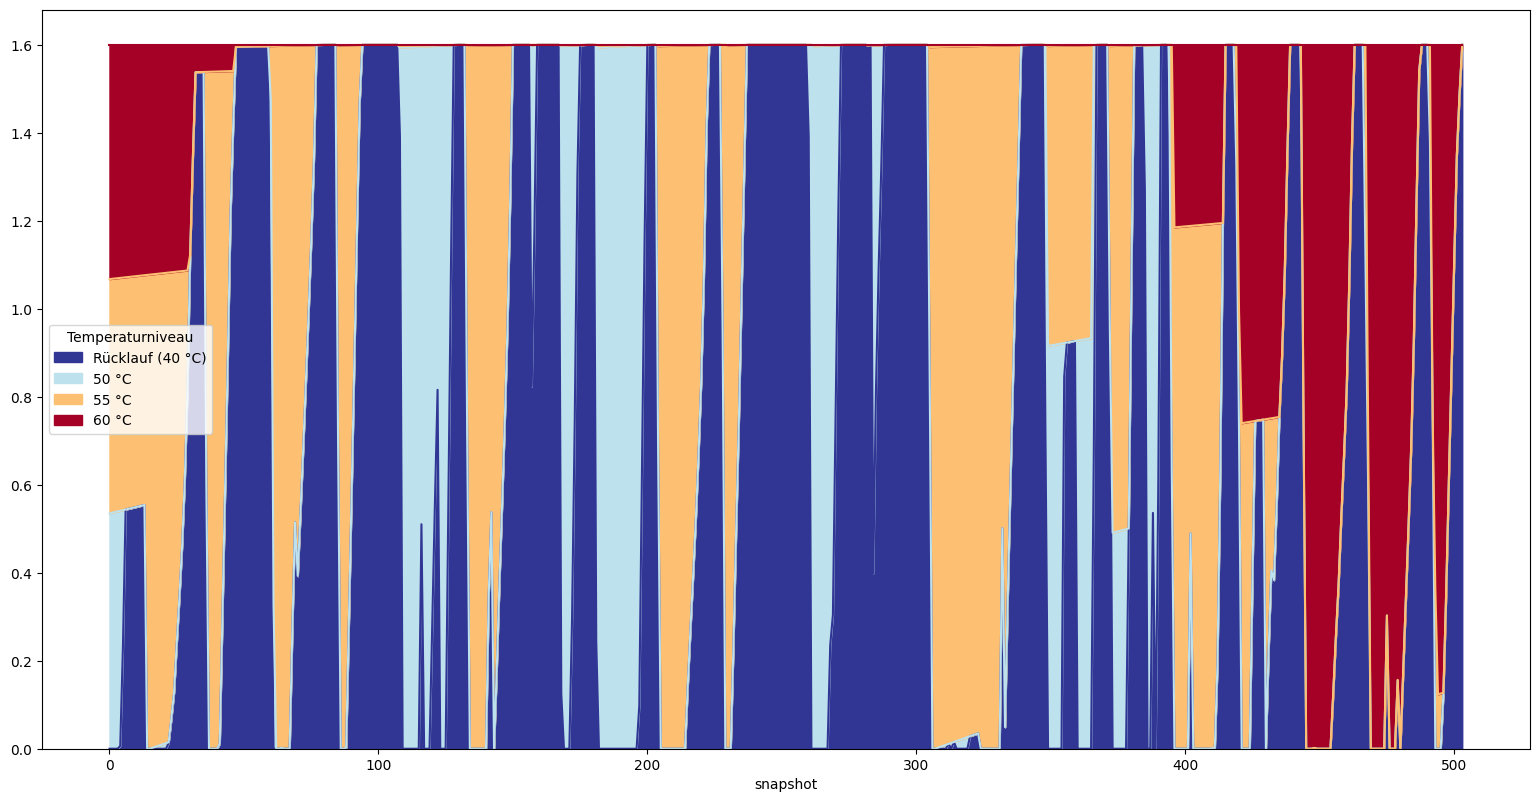

In [ ]:
#ph.plot.plot_stratified_heat_store(n, 'hs', sns = n.snapshots)

df = n.heat_stores_t.V.clip(lower=0)
df.insert(3, 'Rücklauf (40 °C)', ((Store_base * Store_height) - df.sum(axis=1)).clip(lower=0))
df.columns = ['60 °C', '55 °C', '50 °C', 'Rücklauf (40 °C)']
df = df.iloc[:, ::-1]
ax = df.plot(kind='area', stacked=True, figsize=(19.2, 9.6), cmap='RdYlBu_r')
ax.legend(title="Temperaturniveau");

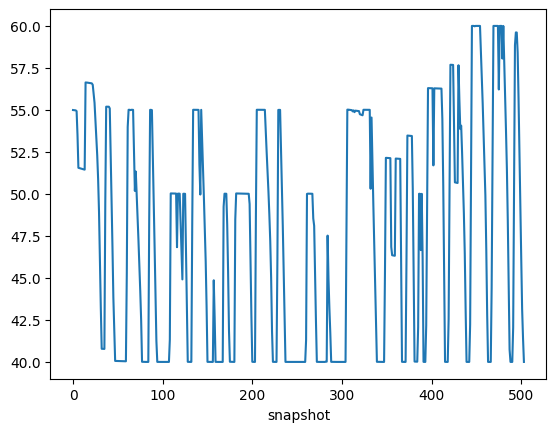

In [ ]:
df = n.heat_stores_t.V.clip(lower=0)
df.columns = ['60 °C', '55 °C', '50 °C']
df.insert(3, 'Rücklauf (40 °C)', ((Store_base * Store_height) - df.sum(axis=1)).clip(lower=0))

temperaturen = [60, 55, 50, 40]
gesamtvolumen = Store_base * Store_height

py_hs_T_avg = (df * temperaturen).sum(axis=1) / gesamtvolumen
py_hs_T_avg.plot();

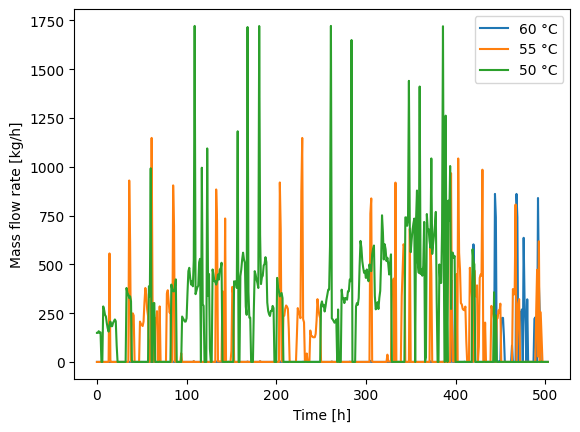

In [ ]:
# Berechnung der Massenströme pro Schicht
m_hs_60 = p_hp_60 / ((0.001161388889) * (60 - T_return.hs))
m_hs_55 = p_hp_55 / ((0.001161388889) * (55 - T_return.hs))
m_hs_50 = p_hp_50 / ((0.001161388889) * (50 - T_return.hs))

ax = m_hs_60.plot(label="60 °C")
m_hs_55.plot(ax=ax, label="55 °C")
m_hs_50.plot(ax=ax, label="50 °C")
ax.legend()
ax.set_ylabel("Mass flow rate [kg/h]")
ax.set_xlabel("Time [h]")

m_hs_total = m_hs_60.add(m_hs_55, fill_value=0).add(m_hs_50, fill_value=0)

In [ ]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 368.47 €


# CSV-Ausgabe

In [ ]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    'py_P_elec': p_elec.hp,
    'py_P_heat_60': p_heat[('hp', 60)],
    'py_P_heat_55': p_heat[('hp', 55)],
    'py_P_heat_50': p_heat[('hp', 50)],
    'py_m_hs_60': m_hs_60,
    'py_m_hs_55': m_hs_55,
    'py_m_hs_50': m_hs_50,
    'py_COP_60': COP[('hp', 60)],
    'py_COP_55': COP[('hp', 55)],
    'py_COP_50': COP[('hp', 50)],
    'py_V_60': v_hs_60,
    'py_V_55': v_hs_55,
    'py_V_50': v_hs_50,
    'py_V_total':  v_hs_60 + v_hs_55 + v_hs_50,
    'py_T_return': T_return.hs,
    'py_P_heat_total': p_heat[('hp', 60)] + p_heat[('hp', 55)] + p_heat[('hp', 50)],
    'm_ges': m_hs_total,
    'T_avg': py_hs_T_avg
})

output_pypsa.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_pypsa.csv",
    sep=",",
    index_label="index",     
)

In [ ]:
output_pypsa

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,py_V_60,py_V_55,py_V_50,py_V_total,py_T_return,py_P_heat_total,m_ges,T_avg
snapshot,,,,,,,,,,,,,,,,,,
0,0.635708,0.0,0.0,1.729125,0.0,0.0,148.884277,2.13,2.41,2.72,0.532650,0.532537,0.534813,1.600000,40.0,1.729125,148.884277,54.993241
1,0.638056,0.0,0.0,1.729133,0.0,0.0,148.884898,2.11,2.39,2.71,0.531968,0.531741,0.536291,1.600000,40.0,1.729133,148.884898,54.986489
2,0.679978,0.0,0.0,1.829140,0.0,0.0,157.495890,2.10,2.38,2.69,0.531286,0.530946,0.537768,1.600000,40.0,1.829140,157.495890,54.979744
3,0.645204,0.0,0.0,1.729147,0.0,0.0,148.886138,2.09,2.37,2.68,0.530605,0.530152,0.539243,1.600000,40.0,1.729147,148.886138,54.973007
4,0.659012,0.0,0.0,1.759561,0.0,0.0,151.504930,2.08,2.36,2.67,0.529925,0.529359,0.534733,1.594017,40.0,1.759561,151.504930,54.928883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.61,1.83,2.07,0.741918,0.000644,0.000829,0.743390,40.0,0.000000,0.000000,49.285189
500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.58,1.79,2.03,0.491576,0.000483,0.000621,0.492679,40.0,0.000000,0.000000,46.153103
501,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.56,1.76,2.00,0.250091,0.000322,0.000414,0.250827,40.0,0.000000,0.000000,43.131742


# TRNSYS Ergebnisse

In [ ]:
TRNSYSinputs = [
    #"Inputs/TRNSYS/TRNSYSMassenstromHausseitig.csv",
    #"Inputs/TRNSYS/TRNSYSRaumwärmebedarf.csv",
    #"Inputs/TRNSYS/TRNSYSRücklauftemperaturKonstanterTemperaturspeicher.csv",
    "Inputs/TRNSYS/konstanterTemperaturspeicher/TRNSYSspeichermitteltemperatur3weeks.csv",
    #"Inputs/TRNSYS/TRNSYSspeicherschichttemperaturen.csv",
    #"Inputs/TRNSYS/TRNSYSWärmepumpe.csv"
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata = TRNSYSdata.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata = TRNSYSdata.round(6)
TRNSYSdata

,Time,ts_T_m
0,0.0,49.829000
1,1.0,53.186205
2,2.0,51.785524
3,3.0,50.463506
4,4.0,49.064884
...,...,...
499,499.0,40.011418
500,500.0,40.008702
501,501.0,40.006687
502,502.0,40.005705


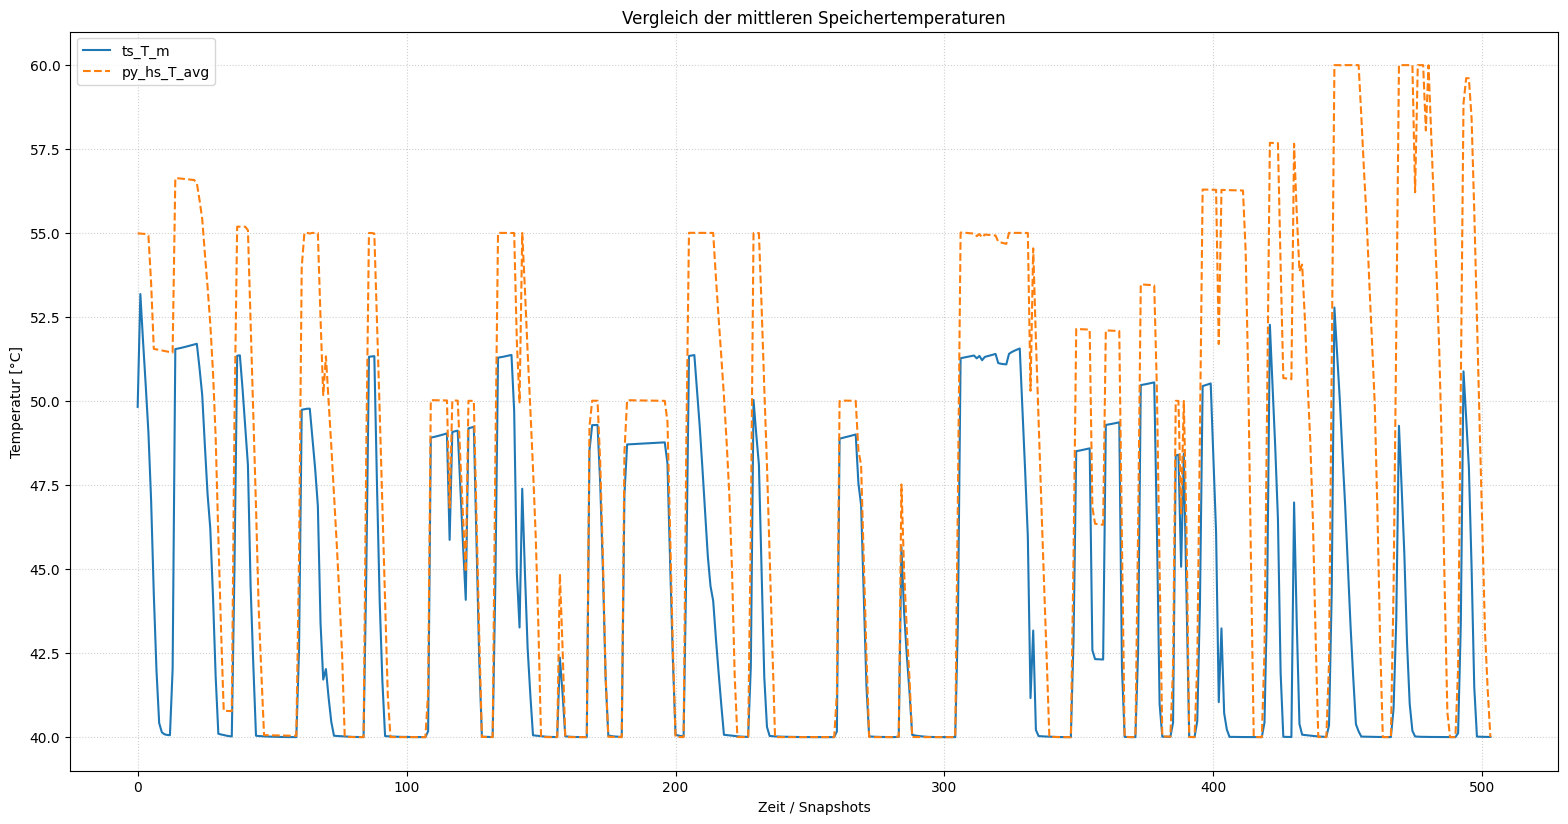

In [ ]:
plt.figure(figsize=(19.2, 9.6))

plt.plot(TRNSYSdata["ts_T_m"].fillna(0), label="ts_T_m")
plt.plot(output_pypsa["T_avg"].fillna(0), label="py_hs_T_avg", linestyle="--")

plt.ylim(39, 61)
plt.xlabel("Zeit / Snapshots")
plt.ylabel("Temperatur [°C]")
plt.title("Vergleich der mittleren Speichertemperaturen")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

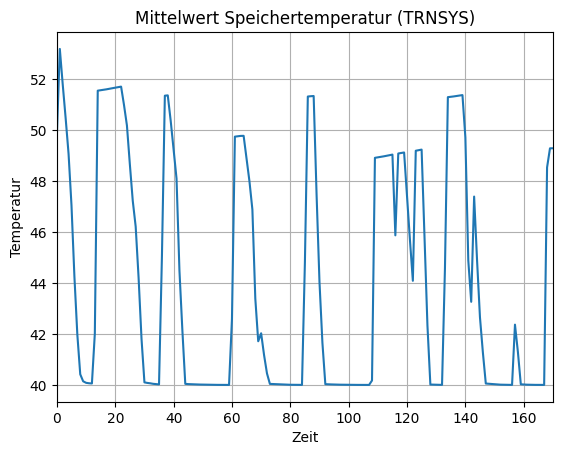

In [ ]:
TRNSYS_T_m = TRNSYSdata['ts_T_m'].copy()

TRNSYS_T_m.plot()
plt.title('Mittelwert Speichertemperatur (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher/ts_speicherschichten_m.png')
plt.show()

In [ ]:
output_combined = pd.concat([output_pypsa, TRNSYSdata], axis=1)
output_combined

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,py_V_60,py_V_55,py_V_50,py_V_total,py_T_return,py_P_heat_total,m_ges,T_avg,Time,ts_T_m
0,0.635708,0.0,0.0,1.729125,0.0,0.0,148.884277,2.13,2.41,2.72,0.532650,0.532537,0.534813,1.600000,40.0,1.729125,148.884277,54.993241,0.0,49.829000
1,0.638056,0.0,0.0,1.729133,0.0,0.0,148.884898,2.11,2.39,2.71,0.531968,0.531741,0.536291,1.600000,40.0,1.729133,148.884898,54.986489,1.0,53.186205
2,0.679978,0.0,0.0,1.829140,0.0,0.0,157.495890,2.10,2.38,2.69,0.531286,0.530946,0.537768,1.600000,40.0,1.829140,157.495890,54.979744,2.0,51.785524
3,0.645204,0.0,0.0,1.729147,0.0,0.0,148.886138,2.09,2.37,2.68,0.530605,0.530152,0.539243,1.600000,40.0,1.729147,148.886138,54.973007,3.0,50.463506
4,0.659012,0.0,0.0,1.759561,0.0,0.0,151.504930,2.08,2.36,2.67,0.529925,0.529359,0.534733,1.594017,40.0,1.759561,151.504930,54.928883,4.0,49.064884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.61,1.83,2.07,0.741918,0.000644,0.000829,0.743390,40.0,0.000000,0.000000,49.285189,499.0,40.011418
500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.58,1.79,2.03,0.491576,0.000483,0.000621,0.492679,40.0,0.000000,0.000000,46.153103,500.0,40.008702
501,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.56,1.76,2.00,0.250091,0.000322,0.000414,0.250827,40.0,0.000000,0.000000,43.131742,501.0,40.006687
502,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.55,1.75,1.98,0.112073,0.000161,0.000207,0.112440,40.0,0.000000,0.000000,41.403707,502.0,40.005705


In [ ]:
output_combined_ordered = output_combined#.iloc[:, [ 13, 17, 18, 19, 20, 16, 15, 14, 11,10,12, 0, 1, 4, 7, 2, 5, 8, 3, 6, 9]]
output_combined_ordered.to_csv(
    "Outputs/konstanterTemperaturspeicher/output_combined_ordered.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)
output_combined_ordered

,py_P_elec,py_P_heat_60,py_P_heat_55,py_P_heat_50,py_m_hs_60,py_m_hs_55,py_m_hs_50,py_COP_60,py_COP_55,py_COP_50,py_V_60,py_V_55,py_V_50,py_V_total,py_T_return,py_P_heat_total,m_ges,T_avg,Time,ts_T_m
0,0.635708,0.0,0.0,1.729125,0.0,0.0,148.884277,2.13,2.41,2.72,0.532650,0.532537,0.534813,1.600000,40.0,1.729125,148.884277,54.993241,0.0,49.829000
1,0.638056,0.0,0.0,1.729133,0.0,0.0,148.884898,2.11,2.39,2.71,0.531968,0.531741,0.536291,1.600000,40.0,1.729133,148.884898,54.986489,1.0,53.186205
2,0.679978,0.0,0.0,1.829140,0.0,0.0,157.495890,2.10,2.38,2.69,0.531286,0.530946,0.537768,1.600000,40.0,1.829140,157.495890,54.979744,2.0,51.785524
3,0.645204,0.0,0.0,1.729147,0.0,0.0,148.886138,2.09,2.37,2.68,0.530605,0.530152,0.539243,1.600000,40.0,1.729147,148.886138,54.973007,3.0,50.463506
4,0.659012,0.0,0.0,1.759561,0.0,0.0,151.504930,2.08,2.36,2.67,0.529925,0.529359,0.534733,1.594017,40.0,1.759561,151.504930,54.928883,4.0,49.064884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.61,1.83,2.07,0.741918,0.000644,0.000829,0.743390,40.0,0.000000,0.000000,49.285189,499.0,40.011418
500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.58,1.79,2.03,0.491576,0.000483,0.000621,0.492679,40.0,0.000000,0.000000,46.153103,500.0,40.008702
501,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.56,1.76,2.00,0.250091,0.000322,0.000414,0.250827,40.0,0.000000,0.000000,43.131742,501.0,40.006687
502,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,1.55,1.75,1.98,0.112073,0.000161,0.000207,0.112440,40.0,0.000000,0.000000,41.403707,502.0,40.005705


# Combined Plots

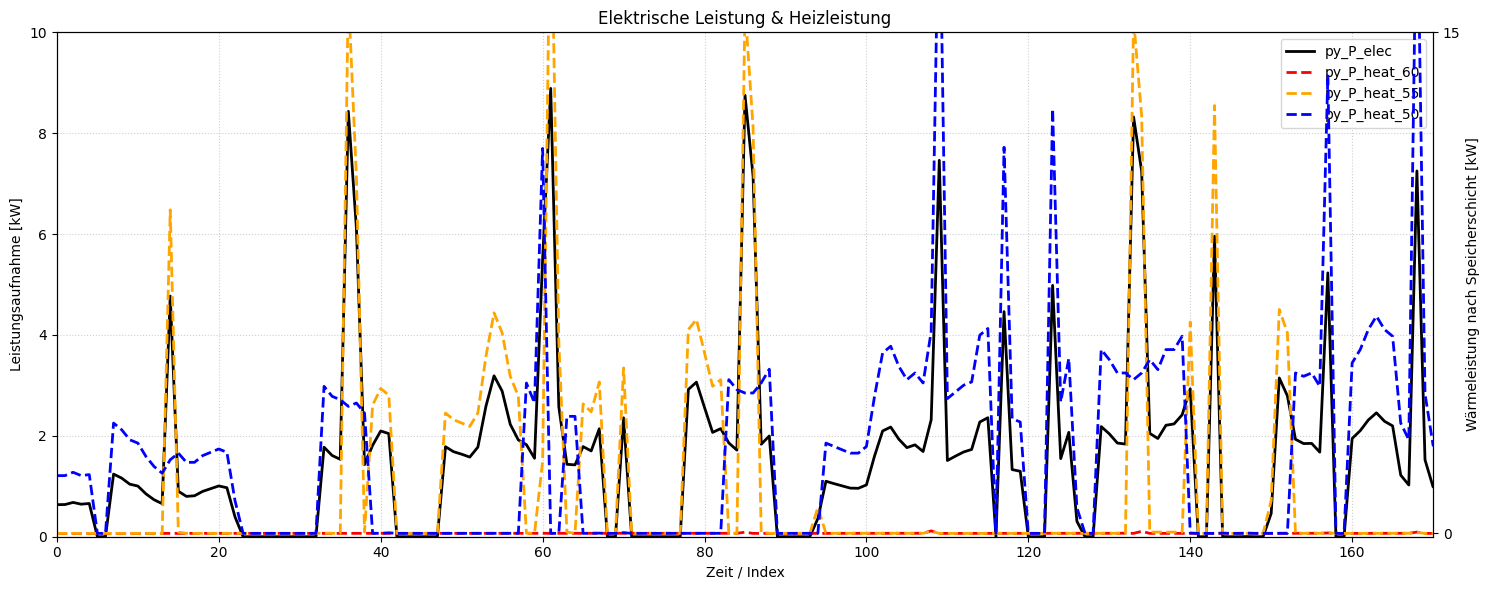

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_elec'], label='py_P_elec', linewidth=2, color='black')
#ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=2, color='dodgerblue')

ax1.set_title('Elektrische Leistung & Heizleistung')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Leistungsaufnahme [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0, 10) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_60'], label='py_P_heat_60', linewidth=2, color='red', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_55'], label='py_P_heat_55', linewidth=2, color='orange', linestyle='--')
ax2.plot(output_pypsa.index,output_combined_ordered['py_P_heat_50'], label='py_P_heat_50', linewidth=2, color='blue', linestyle='--')

ax2.set_ylabel('Wärmeleistung nach Speicherschicht [kW]')
ax2.set_ylim(-0.1, 1.1) # Etwas Puffer nach oben/unten, damit man die Linie besser sieht
ax2.set_yticks([0, 15])  # Nur 0 und 1 anzeigen

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Elektrische Leistung & Heizleistung.png')
plt.show()

KeyError: 'ts_T_R'

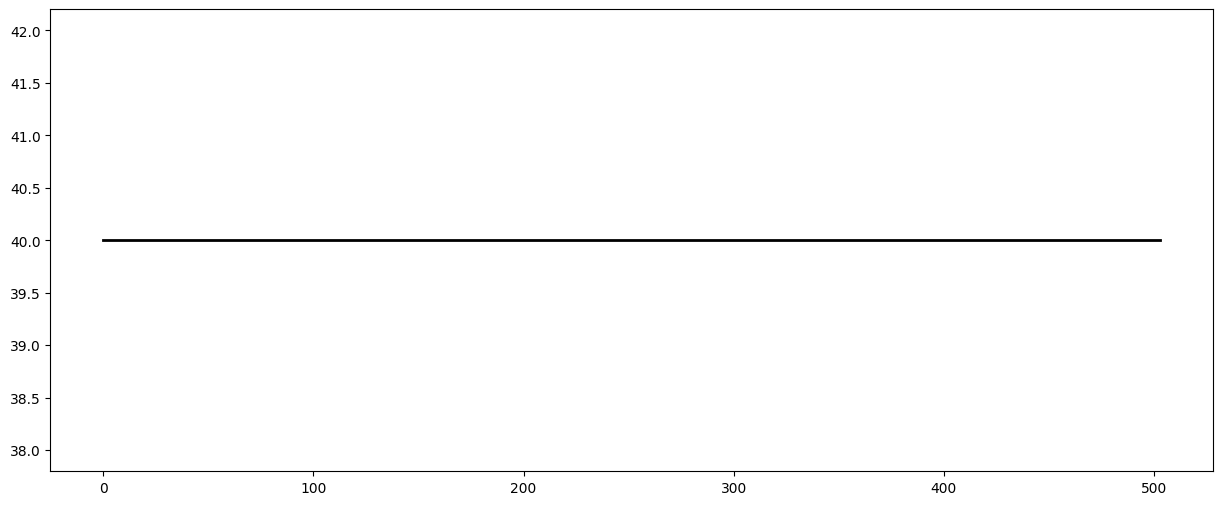

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_T_return'], label='py_T_return', linewidth=2, color='black')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_R'], label='ts_T_R', linewidth=2, color='dodgerblue')

ax1.set_title('Return-Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur [°C]')
ax1.set_xlim(0, 170)
ax1.set_ylim(20,60) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Rücklauftemperatur im Vergleich.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_V_total'], label='py_V_total', linewidth=2, color='black')

ax1.set_title('Volumen in Speicherschichten & Mittelere Temperatur in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Volumen in Speicherschichten [m³]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,1.75) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: Temperaturen ---
ax2 = ax1.twinx()
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='ts_T_m ', linewidth=2, color='dodgerblue')

ax2.set_xlabel('Zeit / Index')
ax2.set_ylabel('Mittlere Temperatur [°C]')
ax2.set_xlim(0, 170)
ax2.set_ylim(25,69) # Beispielhafter Bereich für Temperaturen
ax2.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper left')
ax2.legend(lines2, labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Volumen und Mittlere Temperatur im Vergleich.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index,output_combined_ordered['py_P_heat_total'], label='py_P_heat_total', linewidth=2, color='black')
ax1.plot(output_pypsa.index,output_combined_ordered['ts_P_heat'], label='ts_P_heat', linewidth=2, color='dodgerblue')

ax1.set_title('Heizleistung in Vergleich')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Heizleistung [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(0,20) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Heizleistung in Vergleich.png')

plt.show()

In [ ]:
# Erstelle Figur und Achsen
from numpy import test


fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot((output_combined_ordered['py_P_heat_total'] - output_combined_ordered['ts_P_heat']), label='Differenz zwischen den Heizleistungen', linewidth=2, color='black')


ax1.set_title('Differenz zwischen den Heizleistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Heizleistung [kW]')
ax1.set_xlim(0, 170)
ax1.set_ylim(-20,20) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(lines1, labels1, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher/Differenz zwischen den Heizleistungen.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Kombinierte Daten: Temperaturen und Leistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat'], label='p_heat Python', color='purple', linestyle='-.', linewidth=1.5)
# Optional: Falls TRNSYS Leistung auch geplottet werden soll (Spaltenname p_heat laut deinem CSV-Beispiel)
if 'p_heat' in TRNSYSdata.columns:
    ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_p_heat'], label='p_heat TRNSYS', color='red', linestyle=':', linewidth=1.5)

ax2.set_ylabel('Leistung (kW)')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/vergleich_T_m+p_heat.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen T1, T2 und T3
# Python Daten
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5)

# TRNSYS Daten (gestrichelt für bessere Unterscheidung)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)
ax1.legend() # Fügt die Legende hinzu, um die Linien zu unterscheiden

plt.tight_layout()
plt.show()


In [ ]:
# sharex=True sorgt dafür, dass die X-Achse für alle Plots gleich ist
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

# --- Plot für T1 ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.set_ylabel('Temperatur T1 (°C)')
ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.grid(True)
ax1.legend(loc='upper right')

# --- Plot für T2 ---
ax2.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5, color='orange')
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--', color='red')
ax2.set_ylabel('Temperatur T2 (°C)')
ax2.grid(True)
ax2.legend(loc='upper right')

# --- Plot für T3 ---
ax3.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5, color='green')
ax3.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--', color='brown')
ax3.set_ylabel('Temperatur T3 (°C)')
ax3.set_xlabel('Zeit / Index')
ax3.set_xlim(0, 170)
ax3.grid(True)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Berechnung der Differenzen (Python - TRNSYS)
delta_T_1 = output_pypsa['py_T_1'] - TRNSYSdata['ts_T_1']
delta_T_2 = output_pypsa['py_T_2'] - TRNSYSdata['ts_T_2']
delta_T_3 = output_pypsa['py_T_3'] - TRNSYSdata['ts_T_3']

# Erstelle Figur
fig, ax = plt.subplots(figsize=(15, 6))

# Plotten der Differenzen
ax.plot(output_pypsa.index, delta_T_1, label='Δ T1')
ax.plot(output_pypsa.index, delta_T_2, label='Δ T2')
ax.plot(output_pypsa.index, delta_T_3, label='Δ T3')

# Null-Linie als Referenz (Zentrum)
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

# Achseneinstellungen
ax.set_title('Temperaturdifferenzen: Python - TRNSYS')
ax.set_xlabel('Zeit / Index')
ax.set_ylabel('Abweichung [K]')
ax.set_xlim(0, 170)

# Symmetrische Y-Achse für Null in der Mitte
limit = max(abs(delta_T_1).max(), abs(delta_T_2).max(), abs(delta_T_3).max()) * 1.1
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata['ts_T_m']

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='Δ T_m', color='black')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Abweichung [K]')
ax1.tick_params(axis='y')

ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx() 
ax2.plot(output_combined.index, output_combined.py_P_heat, label='P_heat', color='red', alpha=0.6)
ax2.set_ylabel('Leistung [W] / [kW]') 
ax2.tick_params(axis='y')

plt.title('Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlim(0, 170)
plt.tight_layout()
plt.show()

In [ ]:
correlation_cols = [
    'py_P_heat', 
    'py_m_flow', 
    'ts_P_heatspace'
]

matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)

plt.title('Korrelationsmatrix: Systemschnittstellen vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
delta_T_m.sum()